# Overfitting and Underfitting

In machine learning, a model can make two main mistakes:

1. Underfitting:
   - The model is too simple.
   - It cannot capture the real pattern in the data.
   - It performs poorly on both training and test data.
   - This is called high bias.
   - Example: a straight line trying to fit a curved dataset.

2. Overfitting:
   - The model is too complex.
   - It learns the training data too well, including noise.
   - It performs very well on training data but badly on new data.
   - This is called high variance.
   - Example: a very flexible curve that twists around every point.

3. Good fit:
   - The model is balanced.
   - It learns the true pattern without memorizing noise.
   - This gives the best generalization to unseen data.

The visualization below compares these three situations:
- left: underfitting
- middle: good fit
- right: overfitting

The goal is to choose a model with the right complexity, not too simple and not too complex.

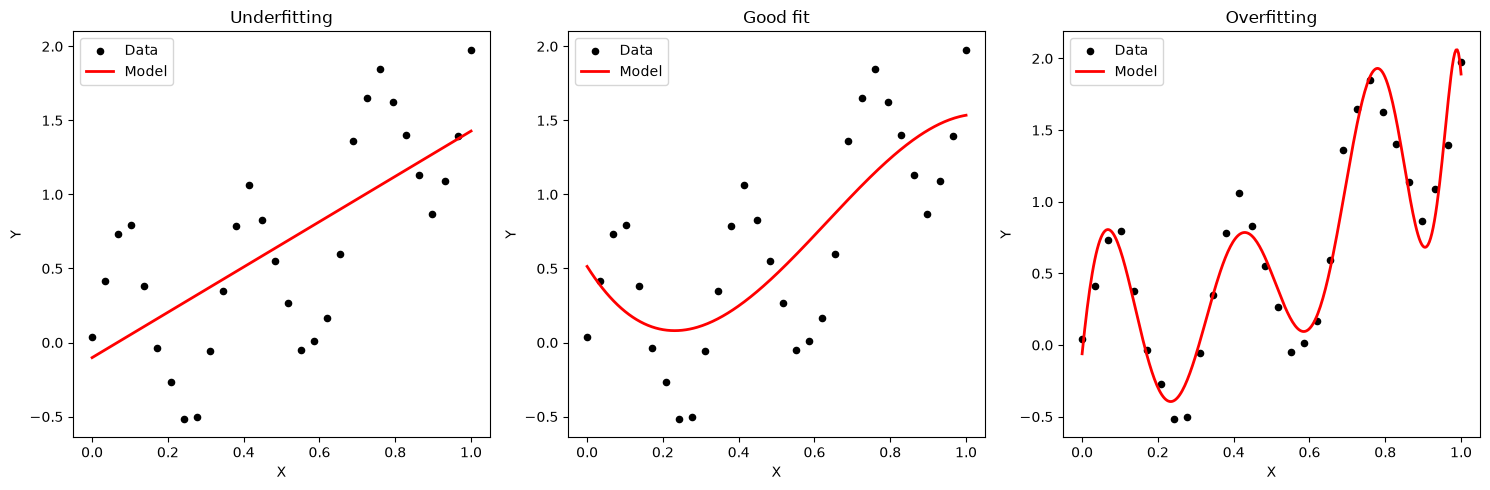

In [22]:
# Overfitting and Underfitting Visualization
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

np.random.seed(42)
x = np.linspace(0, 1, 30)
y = 2 * x**2 + 0.7 * np.sin(6 * np.pi * x) + 0.08 * np.random.randn(30)

models = {
    "Underfitting": 1,
    "Good fit": 3,
    "Overfitting": 12,
}

plt.figure(figsize=(15, 5))
for i, (name, degree) in enumerate(models.items(), 1):
    plt.subplot(1, 3, i)
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(x.reshape(-1, 1), y)

    x_test = np.linspace(0, 1, 300)
    y_pred = model.predict(x_test.reshape(-1, 1))

    plt.scatter(x, y, color="black", s=20, label="Data")
    plt.plot(x_test, y_pred, color="red", linewidth=2, label="Model")
    plt.title(name)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()

plt.tight_layout()
plt.show()

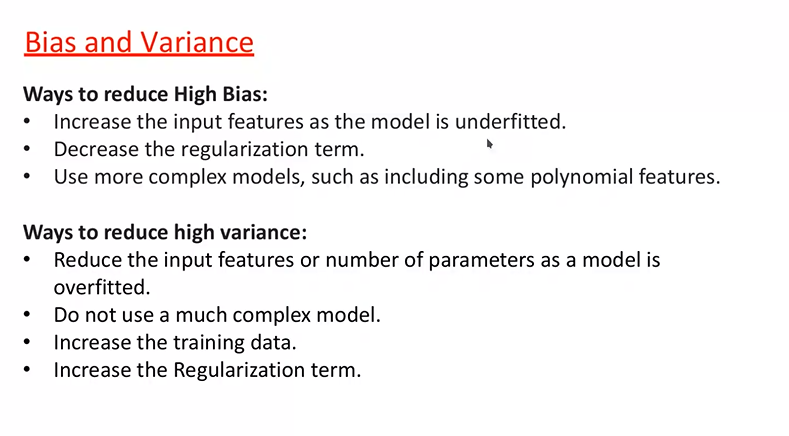

## Bias and Variance

- Bias: the error caused by a model that is too simple.
  - It cannot learn the true pattern in the data.
  - This leads to underfitting.
  - High bias means the model makes strong assumptions and misses important relationships.

- Variance: the error caused by a model that is too complex.
  - It fits the training data too closely and becomes sensitive to small changes in the data.
  - This leads to overfitting.
  - High variance means the model learns noise instead of the real pattern.

### Bias-Variance Tradeoff
As model complexity increases:
- bias usually decreases
- variance usually increases

The best model is the one that balances both.

A useful visualization is a curve showing train error and validation/test error:
- training error keeps decreasing as the model becomes more complex
- test error decreases first, then starts increasing after the best point

This is the classic bias-variance tradeoff.

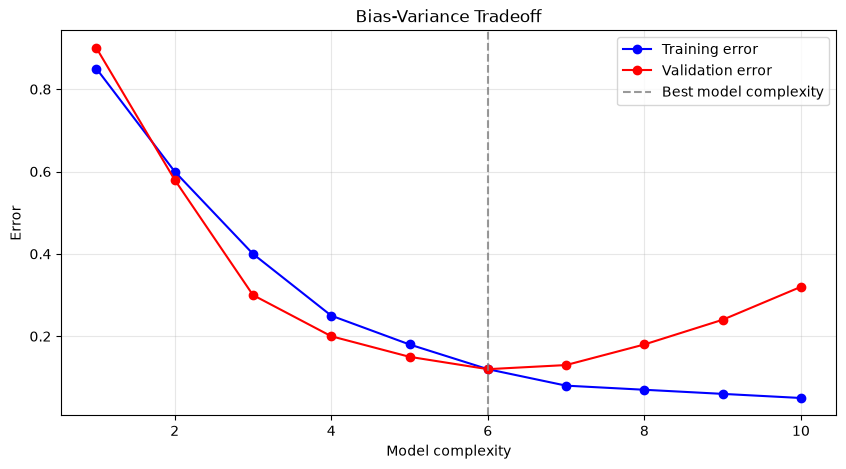

Low complexity -> high bias -> underfitting
High complexity -> high variance -> overfitting
Balanced complexity -> best generalization


In [23]:
# Bias-Variance visualization
import numpy as np
import matplotlib.pyplot as plt

# Example of model complexity vs errors
complexity = np.arange(1, 11)
train_error = np.array([0.85, 0.60, 0.40, 0.25, 0.18, 0.12, 0.08, 0.07, 0.06, 0.05])
val_error = np.array([0.90, 0.58, 0.30, 0.20, 0.15, 0.12, 0.13, 0.18, 0.24, 0.32])

plt.figure(figsize=(10, 5))
plt.plot(complexity, train_error, label='Training error', color='blue', marker='o')
plt.plot(complexity, val_error, label='Validation error', color='red', marker='o')
plt.axvline(6, color='gray', linestyle='--', alpha=0.8, label='Best model complexity')
plt.title('Bias-Variance Tradeoff')
plt.xlabel('Model complexity')
plt.ylabel('Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Simple explanation text
print("Low complexity -> high bias -> underfitting")
print("High complexity -> high variance -> overfitting")
print("Balanced complexity -> best generalization")

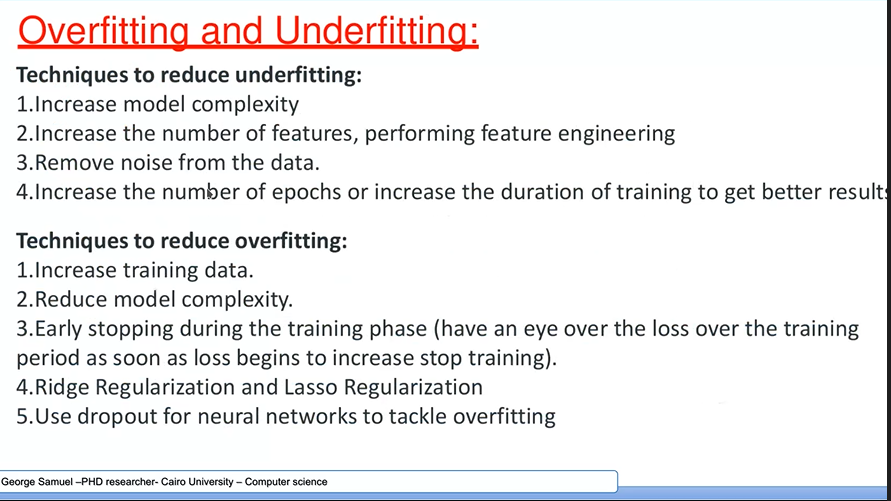

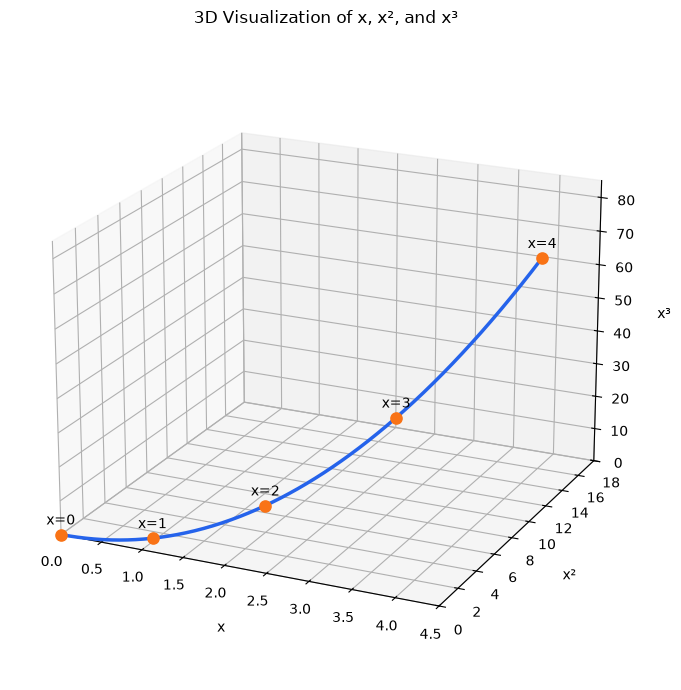

In [24]:
# 3D visualization of the curve (x, x^2, x^3)
import numpy as np
import matplotlib.pyplot as plt

x_curve = np.linspace(0, 4, 300)
y_curve = x_curve**2
z_curve = x_curve**3

x_points = np.arange(0, 5)
y_points = x_points**2
z_points = x_points**3

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot(x_curve, y_curve, z_curve, color="#2563eb", linewidth=2.5)
ax.scatter(x_points, y_points, z_points, color="#f97316", s=65, depthshade=False)

for x_value, y_value, z_value in zip(x_points, y_points, z_points):
    ax.text(x_value, y_value, z_value + 3, f"x={x_value}", fontsize=10, ha="center")

ax.set_xlabel("x", labelpad=10)
ax.set_ylabel("x²", labelpad=10)
ax.set_zlabel("x³", labelpad=10)
ax.set_title("3D Visualization of x, x², and x³", pad=18)
ax.set_xlim(0, 4.5)
ax.set_ylim(0, 18)
ax.set_zlim(0, 85)
ax.view_init(elev=20, azim=-65)
ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot  as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
 

In [26]:
df = pd.read_csv("Salary_Data.csv")

In [27]:
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [28]:
x = df.iloc[:, :-1].values
y = df.iloc[:, 1].values
x_train , x_test , y_train , y_test = train_test_split(x, y, test_size=0.8, random_state=10)

In [29]:
from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree=15)
x_poly_train = poly_reg.fit_transform(x_train)
x_poly_test = poly_reg.transform(x_test)

In [ ]:
poly_model = LinearRegression()
poly_model.fit(x_poly_train, y_train)
y_poly_pred_train = poly_model.predict(x_poly_train)
y_poly_pred_test = poly_model.predict(x_poly_test)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](16,)","[ 0. , 0. , 0. ,...,-0.02, 0. ,-0. ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.951e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,16
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](6,)","[6.77e+10,3.85e+08,2.61e+06,1.02e+05,5.22e+02,6.22e-07]"


In [ ]:
x_range = np.linspace(x.min(),x.max() , 100).reshape(-1,1)
x_range_poly = poly.transform(x_range)
y_range_pred = poly_model.predict(x_range_poly)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9278.75]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.443e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[3.87]


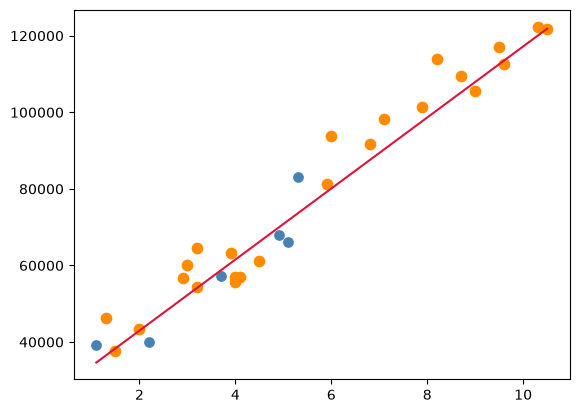

In [32]:
plt.scatter(x_train , y_train , color = "steelblue" , s = 45 , label = "Training data")
plt.scatter(x_test , y_test , color = "darkorange" , s = 55 , label = "Actual test data")
plt.plot(x_plot , lin_reg.predict(x_plot) , color = "crimson")